In [ ]:
import os
import re
import sys
import json
import random
import subprocess
import numpy as np
import pandas as pd
from tqdm import tqdm
from simple_colors import *
import os
import fnmatch

import pandas as pd
from collections import defaultdict

module_path = os.path.abspath(os.path.join(''))
if module_path not in sys.path:
    sys.path.append(module_path)


%load_ext autoreload
%autoreload 2

from utils import load_jsonlines, write_jsonlines, PROJECT_ROOT_DIR, DATA_ROOT_DIR, load_json, write_json

/fs/clip-projects/rlab/nehasrik/miniconda3/envs/badq-annotation/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
from community_analysis.ngram import *

In [3]:
import json

community_names = ["AskEconomics", "AskHistorians", "asklinguistics", "history", "ScienceBasedParenting", "beyondthebump", "explainlikeimfive", "NoStupidQuestions", "OutOfTheLoop"] 

humans = {name: load_jsonlines(f"answer_tagging/results/{name}/comments_tagged.jsonl") for name in community_names}

haiku = {f"haiku-{name}": load_jsonlines(f"answer_tagging/results/{name}/claude-haiku-4.5_tagged.jsonl") for name in community_names}
qwen = {f"qwen-{name}": load_jsonlines(f"answer_tagging/results/{name}/Qwen3-32B_processed_tagged.jsonl") for name in community_names}

mimicked = {f"sonnet-mimic-{name}": load_jsonlines(f"answer_tagging/results/{name}/claude-sonnet-4.5_mimic_community_guidelines_tagged.jsonl") for name in ["AskHistorians", "ScienceBasedParenting"]}

sonnet = {f"sonnet-{name}": load_jsonlines(f"answer_tagging/results/{name}/claude-sonnet-4.5_tagged.jsonl") for name in ["AskHistorians", "ScienceBasedParenting"]}

human_models2, human_seqs2, human_matrix2 = train_and_compare(humans, n=2)
# haiku_models2, haiku_seqs2, haiku_matrix2 = train_and_compare(humans, n=2)



AskEconomics: 1781 sequences, 9984 tokens, n=2
AskHistorians: 1867 sequences, 12154 tokens, n=2
asklinguistics: 1901 sequences, 8454 tokens, n=2
history: 2086 sequences, 9365 tokens, n=2
ScienceBasedParenting: 2789 sequences, 13855 tokens, n=2
beyondthebump: 2132 sequences, 9007 tokens, n=2
explainlikeimfive: 2190 sequences, 11156 tokens, n=2
NoStupidQuestions: 2068 sequences, 7125 tokens, n=2
OutOfTheLoop: 2123 sequences, 10138 tokens, n=2


Picking out cross-community examples with similar discotraces

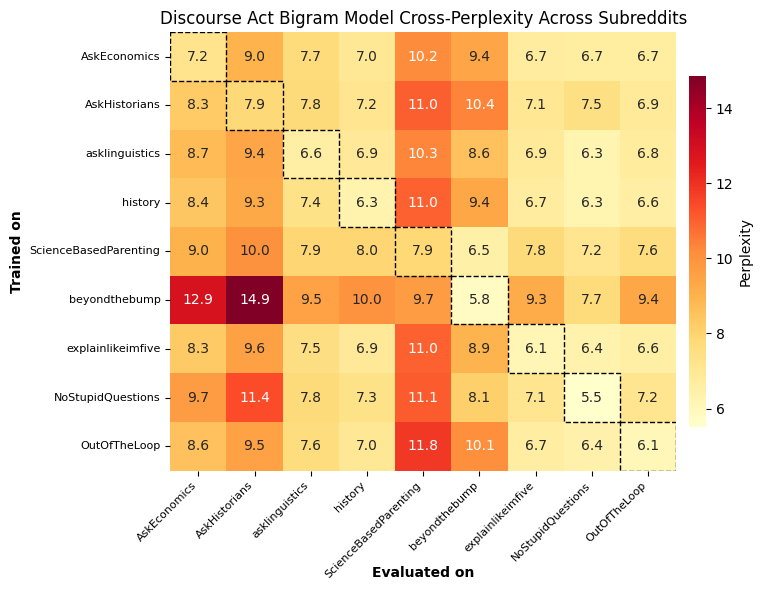

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ngram import plot_perplexity_heatmap

plot_perplexity_heatmap(
    human_matrix2, 
    humans.keys(), 
    humans.keys(), 
    "Discourse Act Bigram Model Cross-Perplexity Across Subreddits", 
    save=True,
    save_name="../figures/human_communities.pdf",
)

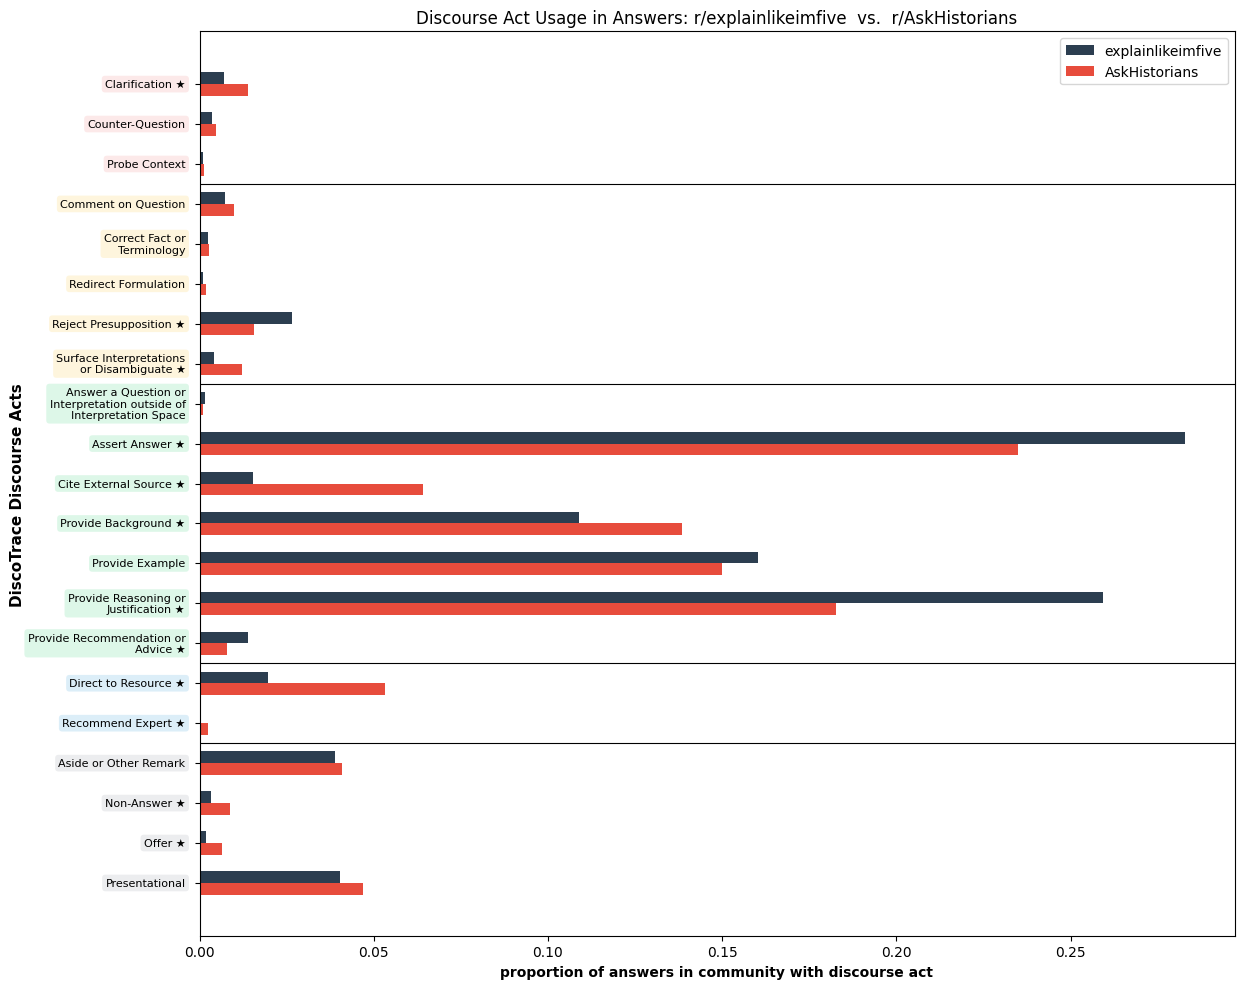

In [8]:
from ngram import plot_two_subs

fig, ax = plot_two_subs(human_models2, ontology, "explainlikeimfive", "AskHistorians")

In [ ]:
fig.savefig('../figures/eli5_v_askhistorians.pdf')

In [8]:
human_models_models2, human_models_seqs2, human_models_matrix2 = train_and_compare(humans | haiku | qwen, n=2)

AskEconomics: 1781 sequences, 9984 tokens, n=2
AskHistorians: 1867 sequences, 12154 tokens, n=2
asklinguistics: 1901 sequences, 8454 tokens, n=2
history: 2086 sequences, 9365 tokens, n=2
ScienceBasedParenting: 2789 sequences, 13855 tokens, n=2
beyondthebump: 2132 sequences, 9007 tokens, n=2
explainlikeimfive: 2190 sequences, 11156 tokens, n=2
NoStupidQuestions: 2068 sequences, 7125 tokens, n=2
OutOfTheLoop: 2123 sequences, 10138 tokens, n=2
haiku-AskEconomics: 300 sequences, 2466 tokens, n=2
haiku-AskHistorians: 300 sequences, 2215 tokens, n=2
haiku-asklinguistics: 300 sequences, 2564 tokens, n=2
haiku-history: 300 sequences, 2116 tokens, n=2
haiku-ScienceBasedParenting: 300 sequences, 2384 tokens, n=2
haiku-beyondthebump: 300 sequences, 2225 tokens, n=2
haiku-explainlikeimfive: 300 sequences, 2423 tokens, n=2
haiku-NoStupidQuestions: 300 sequences, 2195 tokens, n=2
haiku-OutOfTheLoop: 300 sequences, 1955 tokens, n=2
qwen-AskEconomics: 300 sequences, 4620 tokens, n=2
qwen-AskHistorians

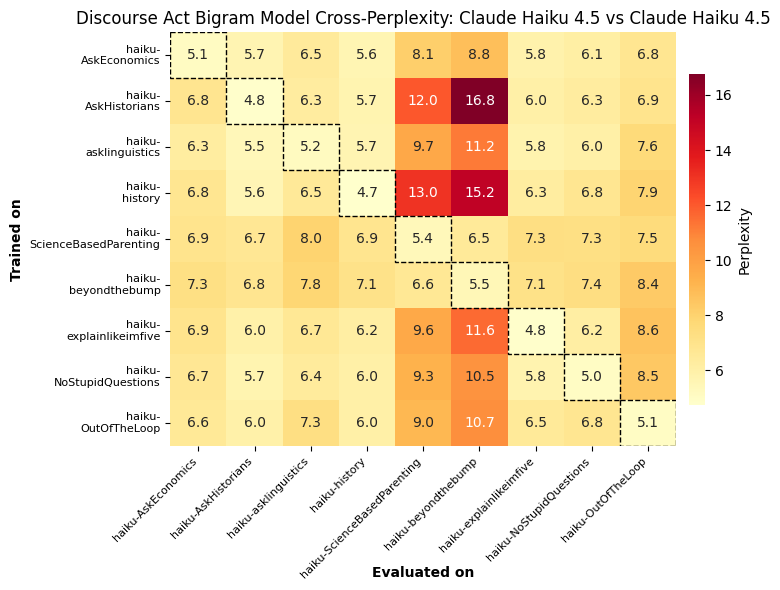

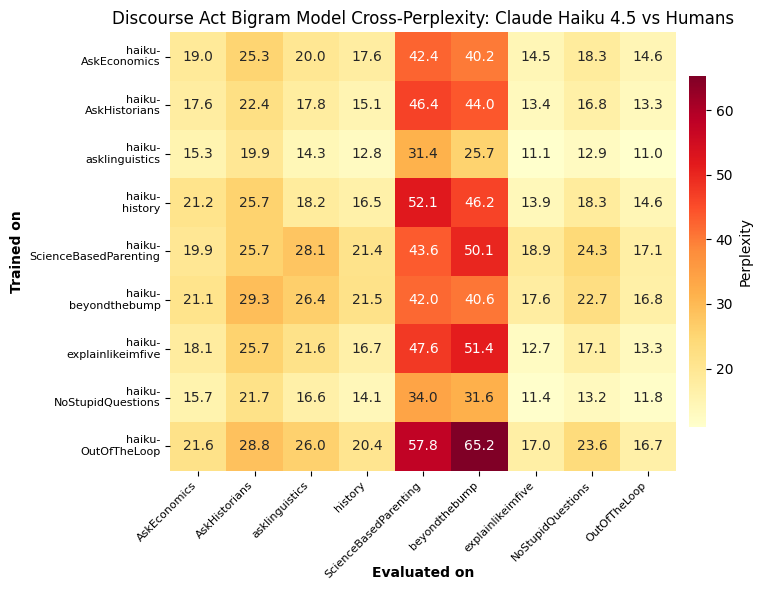

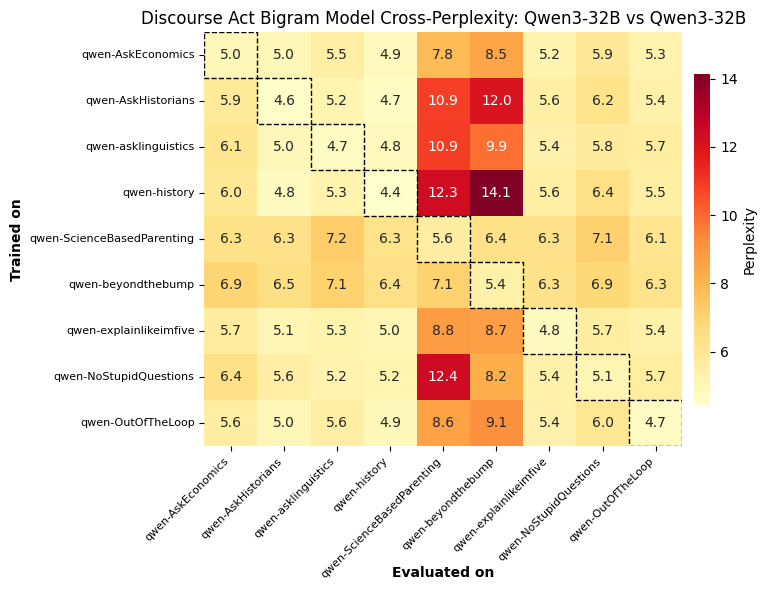

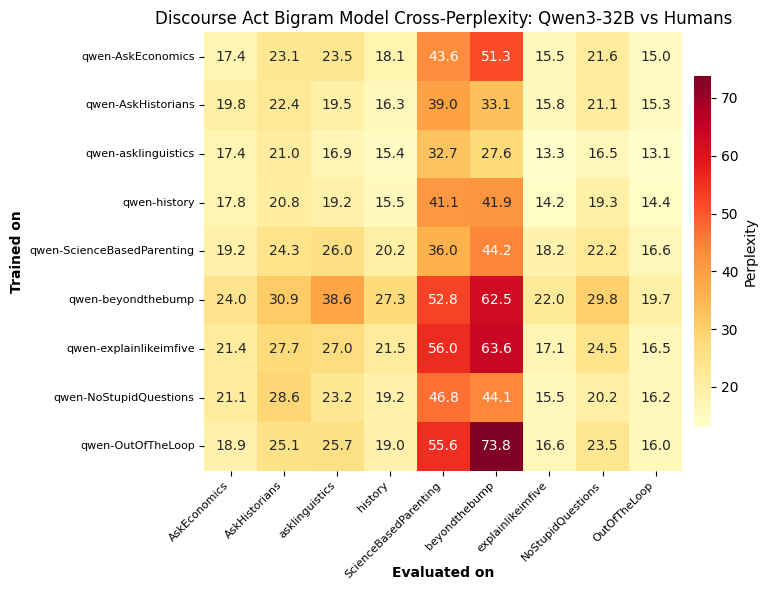

In [9]:
plot_perplexity_heatmap(
    human_models_matrix2, 
    haiku.keys(), 
    haiku.keys(), 
    "Discourse Act Bigram Model Cross-Perplexity: Claude Haiku 4.5 vs Claude Haiku 4.5",
    save=True,
    wrap_yticks=True,
    save_name="../figures/haiku_v_haiku.pdf",
)
plot_perplexity_heatmap(
    human_models_matrix2, 
    haiku.keys(), 
    humans.keys(), 
    "Discourse Act Bigram Model Cross-Perplexity: Claude Haiku 4.5 vs Humans",
    save=True,
    wrap_yticks=True,
    save_name="../figures/haiku_v_human.pdf",
)

plot_perplexity_heatmap(
    human_models_matrix2, 
    qwen.keys(), 
    qwen.keys(), 
    "Discourse Act Bigram Model Cross-Perplexity: Qwen3-32B vs Qwen3-32B",
    save=True,
    save_name="../figures/qwen_v_qwen.pdf",
)

plot_perplexity_heatmap(
    human_models_matrix2, 
    qwen.keys(), 
    humans.keys(), 
    "Discourse Act Bigram Model Cross-Perplexity: Qwen3-32B vs Humans",
    save=True,
    save_name="../figures/qwen_v_human.pdf",
)

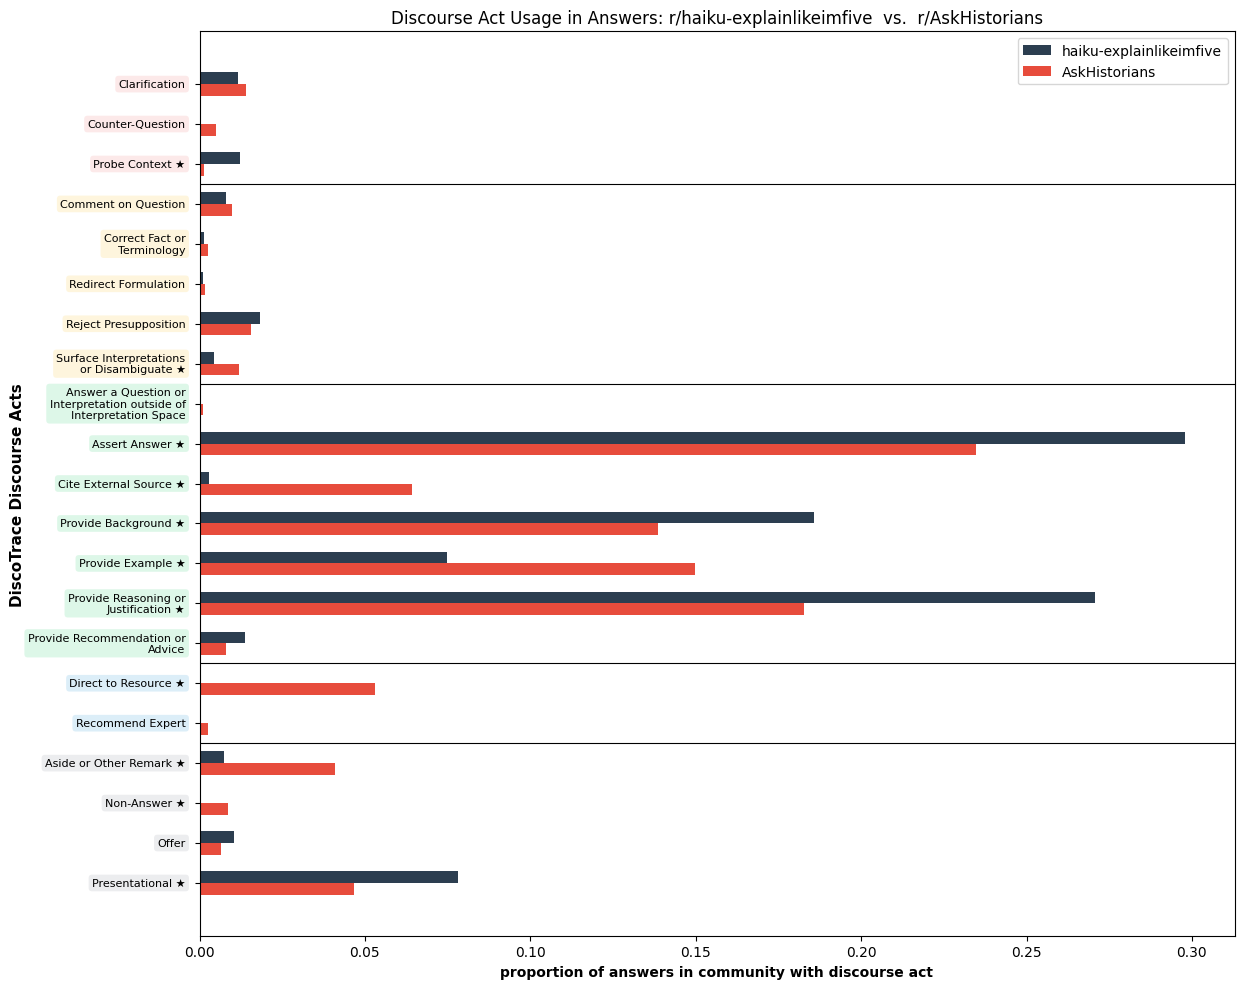

In [10]:
from ngram import plot_two_subs

fig, ax = plot_two_subs(human_models_models2, ontology, "haiku-explainlikeimfive", "AskHistorians")

In [11]:
mimicked_models2, mimicked_seqs2, mimicked_matrix2 = train_and_compare(humans | sonnet | mimicked , n=2)

AskEconomics: 1781 sequences, 9984 tokens, n=2
AskHistorians: 1867 sequences, 12154 tokens, n=2
asklinguistics: 1901 sequences, 8454 tokens, n=2
history: 2086 sequences, 9365 tokens, n=2
ScienceBasedParenting: 2789 sequences, 13855 tokens, n=2
beyondthebump: 2132 sequences, 9007 tokens, n=2
explainlikeimfive: 2190 sequences, 11156 tokens, n=2
NoStupidQuestions: 2068 sequences, 7125 tokens, n=2
OutOfTheLoop: 2123 sequences, 10138 tokens, n=2
sonnet-AskHistorians: 300 sequences, 2225 tokens, n=2
sonnet-ScienceBasedParenting: 300 sequences, 2308 tokens, n=2
sonnet-mimic-AskHistorians: 300 sequences, 5153 tokens, n=2
sonnet-mimic-ScienceBasedParenting: 295 sequences, 2228 tokens, n=2


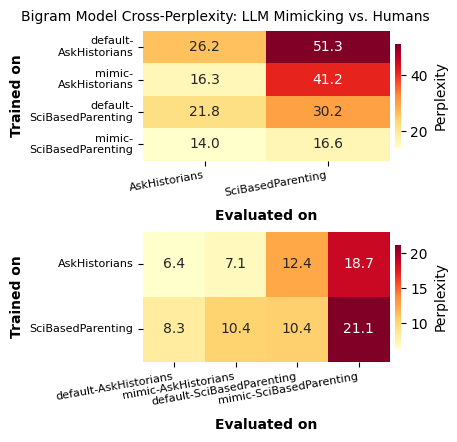

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4.6, 4.6))

plot_perplexity_heatmap(
    mimicked_matrix2,
    ["sonnet-AskHistorians", "sonnet-mimic-AskHistorians", "sonnet-ScienceBasedParenting","sonnet-mimic-ScienceBasedParenting"],
    ["AskHistorians", "ScienceBasedParenting"],
    title=None,
    ax=ax1,
)

plot_perplexity_heatmap(
    mimicked_matrix2,
    ["AskHistorians", "ScienceBasedParenting"],
    ["sonnet-AskHistorians", "sonnet-mimic-AskHistorians", "sonnet-ScienceBasedParenting","sonnet-mimic-ScienceBasedParenting"],
    title=None,
    ax=ax2,
)

abbrev = {
    "sonnet-AskHistorians": "default-AskHistorians",
    "sonnet-ScienceBasedParenting": "default-SciBasedParenting",
    "sonnet-mimic-AskHistorians": "mimic-AskHistorians",
    "sonnet-mimic-ScienceBasedParenting": "mimic-SciBasedParenting",
    "AskHistorians": "AskHistorians",
    "ScienceBasedParenting": "SciBasedParenting",
}

fig.suptitle("Bigram Model Cross-Perplexity: LLM Mimicking vs. Humans", fontsize=10, y=0.95)

for ax in [ax1, ax2]:
    ax.set_xticklabels([abbrev.get(l.get_text(), l.get_text()) for l in ax.get_xticklabels()], rotation=10, ha="right", fontsize=8)
    yticks = [abbrev.get(l.get_text(), l.get_text()) for l in ax.get_yticklabels()]
    yticks_wrapped = [t.replace("-", "-\n", 1) for t in yticks]
    ax.set_yticklabels(yticks_wrapped, rotation=0, fontsize=8)
    ax.set_xlabel("Evaluated on", labelpad=8, fontweight="bold")

plt.tight_layout()
plt.subplots_adjust(hspace=0.55)
plt.savefig("../figures/mimic_cross_perplexity.pdf", bbox_inches="tight")
plt.show()